# Retail Demand Forecasting using XGBoost

## Project Overview

Accurate demand forecasting is one of the most important problems in retail supply chain management. Forecasts directly influence inventory planning, replenishment, warehouse utilization, and stock availability.

In this project, a machine learning pipeline is developed using the Walmart Store Sales Forecasting dataset. Historical sales, promotional events, macroeconomic indicators, and engineered time-series features are used to forecast weekly demand.

The resulting demand forecasts are later used by an inventory optimization module implementing a Periodic Review Order-Up-To inventory policy.

---

## Objectives

- Perform exploratory data analysis
- Engineer meaningful time-series features
- Train an XGBoost forecasting model
- Evaluate forecasting performance using business-relevant metrics
- Generate demand forecasts for inventory optimization

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_and_merge
from src.preprocessing import preprocess
from src.feature_engineering import (
    build_features,
    FEATURE_COLS,
)

from src.forecasting import (
    temporal_split,
    train_model,
    predict,
    evaluate,
    feature_importance,
)

## Load Dataset

The Walmart Recruiting Store Sales Forecasting dataset consists of three separate files:

- train.csv
- features.csv
- stores.csv

These datasets are merged into a single analytical dataset before preprocessing.

In [3]:
df = load_and_merge("../data")

print(df.shape)

df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

## Exploratory Data Analysis

Before training the forecasting model, we perform exploratory analysis to understand seasonal demand patterns, store-level performance, and the influence of holidays.

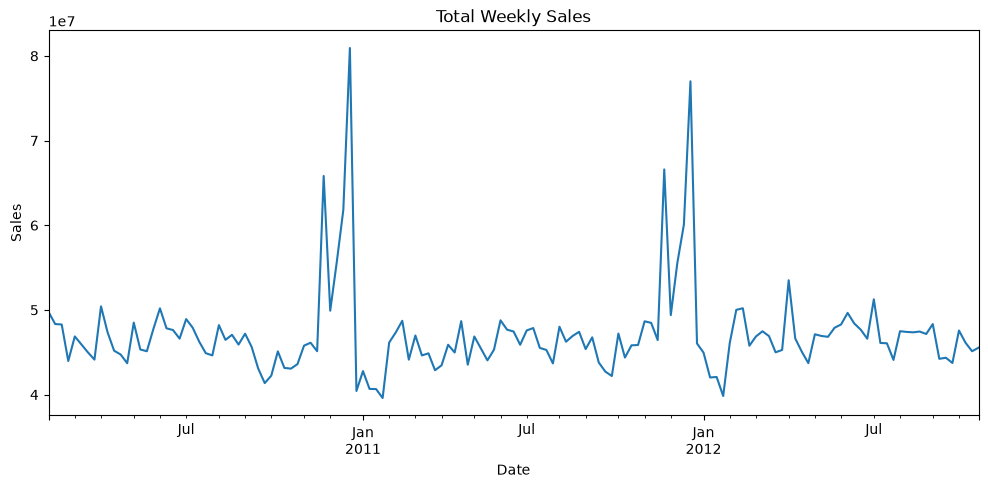

In [5]:
sales = (
    df.groupby("Date")["Weekly_Sales"]
      .sum()
)

plt.figure(figsize=(12,5))

sales.plot()

plt.title("Total Weekly Sales")

plt.ylabel("Sales")

plt.show()

In [6]:
holiday_sales = (
    df.groupby("IsHoliday")["Weekly_Sales"]
      .mean()
)

holiday_sales

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

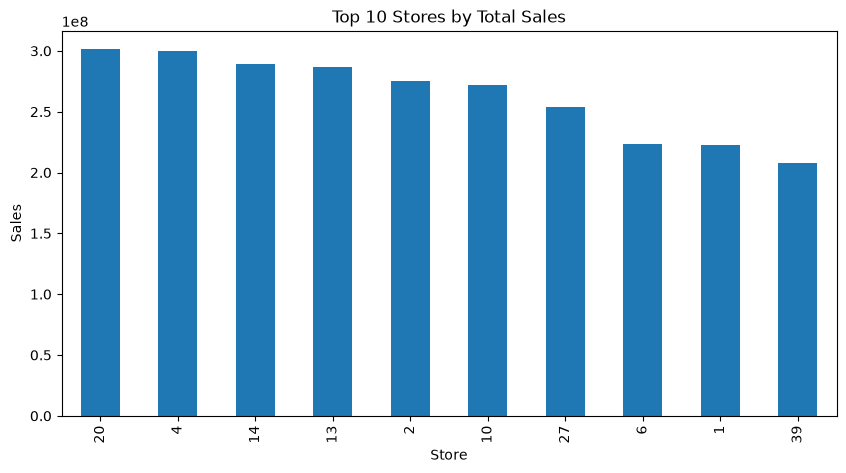

In [7]:
top_stores = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_stores.plot(kind="bar")

plt.title("Top 10 Stores by Total Sales")

plt.ylabel("Sales")

plt.show()

### Observations

- Weekly sales exhibit strong seasonal patterns.
- Holiday weeks generally experience higher sales than regular weeks.
- Sales distribution differs significantly across stores, motivating the inclusion of Store as a predictive feature.

## Data Preprocessing

The raw data contains missing promotional information (MarkDown variables), categorical store types, and requires preprocessing before feature engineering.

Business assumptions:

- Missing markdown values indicate that no promotional markdown was active.
- Store type is one-hot encoded for use by tree-based machine learning models.

In [8]:
df = preprocess(df)
print(df.shape)
df.head()

(421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_B,Type_C
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,151315,0,0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,151315,0,0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,151315,0,0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,151315,0,0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,151315,0,0


## Feature Engineering

Time-series forecasting benefits significantly from historical demand information.

The following features are engineered:

- Calendar features (Year, Month, Week, Quarter)
- Lag features (1, 4, 8 and 12 weeks)
- Rolling averages (4, 8 and 12 weeks)

Lag and rolling features are computed separately for every Store–Department pair to prevent information leakage.

In [9]:
df = build_features(df)

print(df.shape)

df.head()

(382955, 28)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Month,Week,Quarter,Lag_1,Lag_4,Lag_8,Lag_12,Rolling_Mean_4,Rolling_Mean_8,Rolling_Mean_12
0,1,1,2010-04-30,16555.11,False,67.41,2.780,0.0,0.0,0.0,...,4,17,2,16145.35,57258.43,21827.90,24924.50,33490.4125,28149.84875,29763.489167
1,1,1,2010-05-07,17413.94,False,72.55,2.835,0.0,0.0,0.0,...,5,18,2,16555.11,42960.91,21043.39,46039.49,23314.5825,27490.75000,29066.040000
2,1,1,2010-05-14,18926.74,False,74.78,2.854,0.0,0.0,0.0,...,5,19,2,17413.94,17596.96,22136.64,41595.55,16927.8400,27037.06875,26680.577500
3,1,1,2010-05-21,14773.04,False,76.44,2.826,0.0,0.0,0.0,...,5,20,2,18926.74,16145.35,26229.21,19403.54,17260.2850,26635.83125,24791.510000
4,1,1,2010-05-28,15580.43,False,80.44,2.759,0.0,0.0,0.0,...,5,21,2,14773.04,16555.11,57258.43,21827.90,16917.2075,25203.81000,24405.635000


In [10]:
display(df[list(FEATURE_COLS)].head())

,Store,Dept,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Size,Year,Month,...,Rolling_Mean_4,Rolling_Mean_8,Rolling_Mean_12,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Type_B,Type_C
0,1,1,False,67.41,2.780,210.389546,7.808,151315,2010,4,...,33490.4125,28149.84875,29763.489167,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1,False,72.55,2.835,210.339968,7.808,151315,2010,5,...,23314.5825,27490.75000,29066.040000,0.0,0.0,0.0,0.0,0.0,0,0
2,1,1,False,74.78,2.854,210.337426,7.808,151315,2010,5,...,16927.8400,27037.06875,26680.577500,0.0,0.0,0.0,0.0,0.0,0,0
3,1,1,False,76.44,2.826,210.617093,7.808,151315,2010,5,...,17260.2850,26635.83125,24791.510000,0.0,0.0,0.0,0.0,0.0,0,0
4,1,1,False,80.44,2.759,210.896761,7.808,151315,2010,5,...,16917.2075,25203.81000,24405.635000,0.0,0.0,0.0,0.0,0.0,0,0


## Train-Test Split

A chronological split is used instead of a random split.

Training Data:
- Before January 2012

Testing Data:
- January 2012 onwards

This mimics a real forecasting system where future observations are unavailable during training.

In [11]:
train_df, test_df = temporal_split(df)

print(train_df.shape)
print(test_df.shape)

(256034, 28)
(126921, 28)


In [12]:
print(train_df["Date"].min())
print(train_df["Date"].max())

print(test_df["Date"].min())
print(test_df["Date"].max())

2010-04-30 00:00:00
2011-12-30 00:00:00
2012-01-06 00:00:00
2012-10-26 00:00:00


## Model Training

An XGBoost Regressor is trained using the engineered features.

XGBoost was selected because it:

- Handles nonlinear relationships effectively.
- Naturally models feature interactions.
- Requires minimal feature scaling.
- Performs well on structured tabular datasets.

In [13]:
model = train_model(train_df)

In [14]:
test_df["Predicted_Sales"] = predict(
    model,
    test_df,
)

test_df[
    [
        "Weekly_Sales",
        "Predicted_Sales",
    ]
].head()

,Weekly_Sales,Predicted_Sales
88,16567.69,16211.942383
89,16894.40,12784.014648
90,18365.10,15448.281250
91,18378.16,18454.292969
92,23510.49,18845.250000


In [15]:
test_df["Demand_For_Replenishment"] = (
    test_df["Predicted_Sales"]
    .clip(lower=0)
)

## Model Evaluation

The forecasting model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- Weighted Mean Absolute Percentage Error (WMAPE)

WMAPE is preferred over MAPE because the dataset contains zero and negative sales values.

In [16]:
results = evaluate(
    test_df["Weekly_Sales"],
    test_df["Predicted_Sales"],
)

results

{'MAE': 1454.2457711335003,
 'RMSE': 3101.814073409831,
 'R2': 0.9803770394199716,
 'WMAPE': 9.228}

## Feature Importance

XGBoost provides feature importance scores that indicate which variables contribute most to forecasting weekly sales.

This helps validate whether the model is learning meaningful business patterns.

In [17]:
importance = feature_importance(model)

importance.head(15)

,Feature,Importance
0,Rolling_Mean_4,0.419869
1,Lag_1,0.352983
2,Rolling_Mean_8,0.065357
3,Lag_4,0.026235
4,IsHoliday,0.020153
5,MarkDown3,0.013225
6,Week,0.012420
7,Month,0.011086
8,Rolling_Mean_12,0.010644
9,Lag_8,0.006879


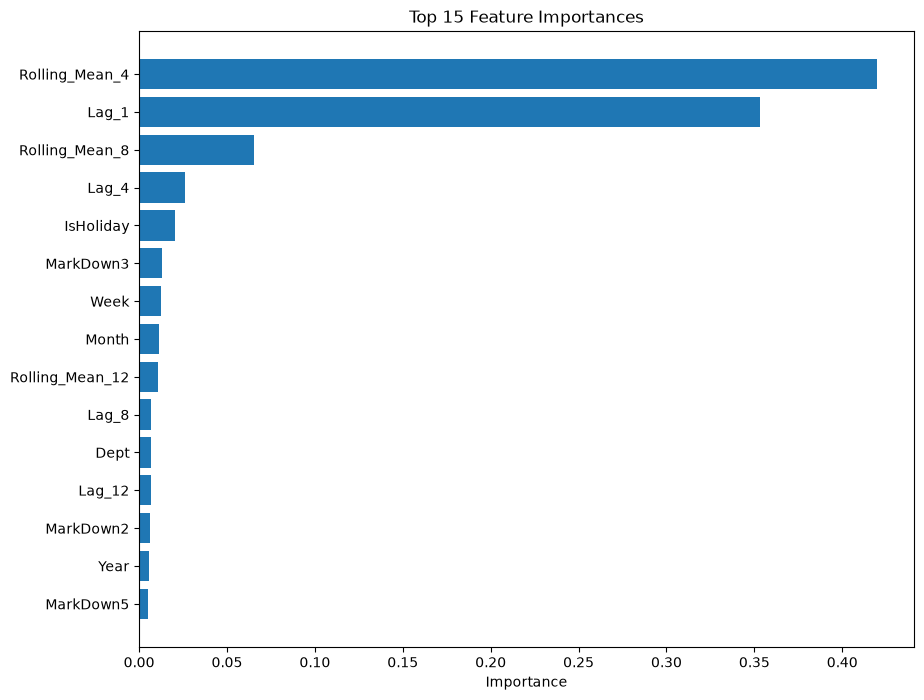

In [18]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:15][::-1],
    importance["Importance"][:15][::-1]
)

plt.xlabel("Importance")

plt.title("Top 15 Feature Importances")

plt.show()

### Interpretation

The model relies primarily on historical sales information through lag and rolling-average features. Promotional markdowns and holiday indicators also contribute to forecast accuracy, demonstrating that both historical demand and business events influence retail sales.

In [19]:
comparison = test_df[
    [
        "Date",
        "Weekly_Sales",
        "Predicted_Sales",
    ]
].copy()

comparison.head()

,Date,Weekly_Sales,Predicted_Sales
88,2012-01-06,16567.69,16211.942383
89,2012-01-13,16894.40,12784.014648
90,2012-01-20,18365.10,15448.281250
91,2012-01-27,18378.16,18454.292969
92,2012-02-03,23510.49,18845.250000


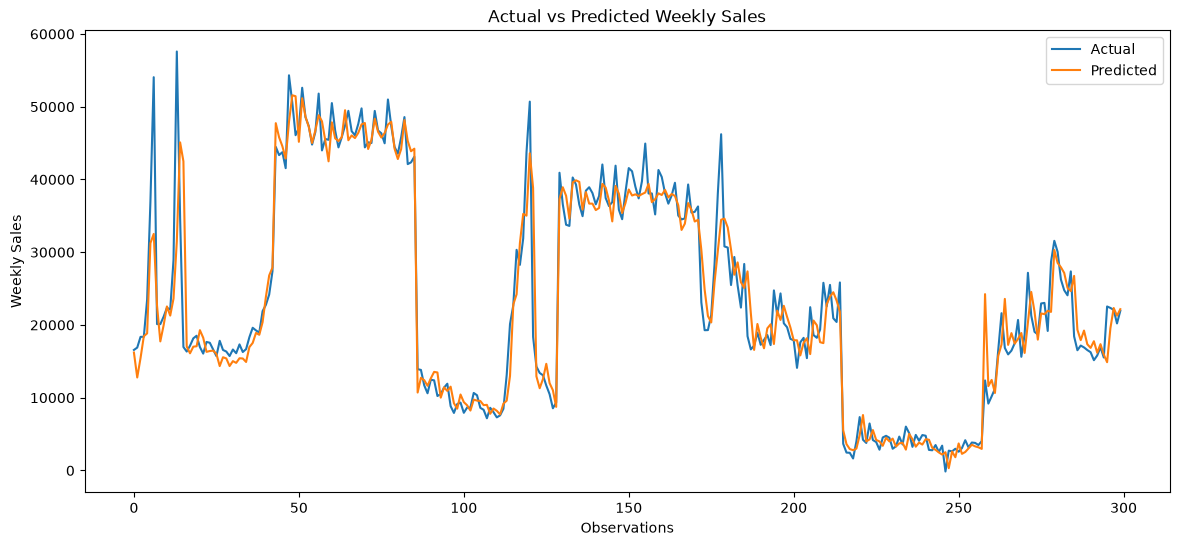

In [20]:
plt.figure(figsize=(14,6))

sample = comparison.iloc[:300]

plt.plot(
    sample["Weekly_Sales"].values,
    label="Actual",
)

plt.plot(
    sample["Predicted_Sales"].values,
    label="Predicted",
)

plt.title("Actual vs Predicted Weekly Sales")

plt.xlabel("Observations")

plt.ylabel("Weekly Sales")

plt.legend()

plt.show()

## Save Trained Model

The trained forecasting model is serialized using Joblib so that it can be reused for downstream inventory optimization without retraining.

In [21]:
from src.utils import save_model

save_model(
    model,
    "../models/xgboost_forecaster.pkl",
)

Model saved → ..\models\xgboost_forecaster.pkl


# Business Conclusions

### Forecasting Performance

- Mean Absolute Error (MAE): **1454**
- Root Mean Squared Error (RMSE): **3102**
- R² Score: **0.980**
- Weighted MAPE: **9.23%**

### Key Findings

- Historical demand (lag and rolling statistics) is the strongest predictor of future sales.
- Promotional markdowns and holidays improve forecast accuracy.
- Temporal train-test splitting avoids data leakage and better reflects real-world forecasting.
- The trained XGBoost model serves as the demand forecasting engine for the downstream inventory optimization module.